What Stage 4 does and why it's structured this waySIMP (Solid Isotropic Material with Penalization) is the topology optimization algorithm. It starts with a uniform density field across all elements — every element is 50% material — and iteratively updates it by solving the FEA problem, computing sensitivities (how much does compliance change if I remove a tiny bit of material here?), and shifting density toward 0 (void) or 1 (solid) based on those sensitivities.The key insight is the penalization: density is raised to a power p (typically 3) before being multiplied into the stiffness. This makes intermediate densities mechanically inefficient — an element at 0.5 density has only 0.5³ = 0.125 of its full stiffness, so the optimizer is pushed toward binary 0/1 solutions rather than a grey mush.The data flow for this stage is:outputs/meshes/<name>_stage03.json       ← handoff from Stage 3
outputs/meshes/<name>.xdmf              ← mesh (re-used for FEA iterations)
outputs/meshes/<name>_boundaries.xdmf   ← BCs (re-used each iteration)
        ↓
src/optimization/density_filter.py       ← smooths density to avoid checkerboard
src/optimization/simp.py                 ← optimization loop
        ↓
outputs/meshes/<name>_density.xdmf       ← final density field
outputs/reports/<name>_density_*.png     ← renders at each checkpoint
outputs/reports/<name>_convergence.png   ← compliance history plot
outputs/meshes/<name>_stage04.json       ← handoff to Stage 5The split between density_filter.py and simp.py is load-bearing — without the filter, SIMP produces checkerboard instability (alternating solid/void elements in a checkerboard pattern that has artificially high stiffness but is physically unmakeable). The filter is what makes the result printable.

Cell 0 — Parameters (tag: parameters)

In [1]:
# Cell 0 — tagged: parameters
import os
os.chdir("/workspace")

import sys
sys.path.insert(0, "/workspace")

PART_NAME_OVERRIDE = None   # set by pipeline_full.ipynb in sweep mode
STAGE03_HANDOFF    = None   # auto-detect if None

# ── Solver selection ──────────────────────────────────────────────────────────
USE_RUST_SOLVER  = True     # False → fall back to FEniCSx simp.py

# ── Voxel grid (Rust path only) ───────────────────────────────────────────────
# Grid is computed from geometry + voxel size.
# 2.5mm → fast dev run; 1.0mm → production quality
VOXEL_SIZE_MM    = 1.0      # mm — element size for structured hex grid

# ── SIMP parameters (shared by both paths) ───────────────────────────────────
VOLUME_FRACTION  = 0.45
PENAL            = 3.0
FILTER_RADIUS    = 2.0      # mm
MAX_ITERATIONS   = 50
CONVERGENCE_TOL  = 0.05
MOVE_LIMIT       = 0.2
CHECKPOINT_EVERY = 10
RENDER_PLOTS     = False

# FEniCSx-only parameters (ignored on Rust path)
USE_ITERATIVE_SOLVER = False

Cell 1 — Load Stage 3 handoff

In [2]:
# Cell 1 — Load params and resolve mesh paths from Stage 3 handoff
from pathlib import Path
import json
from src.geometry.param_schema import PipelineParams

# ── Resolve part name from Stage 3 handoff ────────────────────────────────
if STAGE03_HANDOFF is not None:
    handoff3_path = Path(STAGE03_HANDOFF)
else:
    # Auto-detect: find the most recent stageNN.json to extract part_name
    # Fall back to scanning outputs/meshes/ for *_stage03.json
    candidates = sorted(Path("outputs/meshes").glob("*_stage03.json"))
    assert candidates, \
        "No *_stage03.json found in outputs/meshes/ — run notebook 03 first."
    handoff3_path = candidates[-1]

handoff3     = json.loads(handoff3_path.read_text())
part_name    = PART_NAME_OVERRIDE if PART_NAME_OVERRIDE else handoff3["part_name"]
params_json  = f"scad/{part_name}_params.json"

print(f"Part: {part_name}")
print(f"Params: {params_json}")
print(f"Stage03 handoff: {handoff3_path}")

# ── Load pipeline params ──────────────────────────────────────────────────
pipeline_params = PipelineParams.from_json(params_json)
geometry_params = pipeline_params.geometry
load_hints      = pipeline_params.load_hints   # LoadHints dataclass — used by legacy path
material        = {"youngs_modulus_pa": 210e9, "poissons_ratio": 0.3, "name": "steel"}
baseline_sf     = 99.0

# ── Mesh paths (from Stage 2) ─────────────────────────────────────────────
xdmf_path       = Path("outputs/meshes/opt_domain.xdmf")
boundaries_xdmf = Path("outputs/meshes/opt_domain_boundaries.xdmf")
assert xdmf_path.exists(),       f"Not found: {xdmf_path}"
assert boundaries_xdmf.exists(), f"Not found: {boundaries_xdmf}"
print(f"Mesh: {xdmf_path}")

Part: tripod_mount_base
Params: scad/tripod_mount_base_params.json
Stage03 handoff: outputs/meshes/tripod_mount_base_stage03.json
Mesh: outputs/meshes/opt_domain.xdmf


Cell 2 — Configure SIMP

In [3]:
# Cell 2 — Build solver config
#
# Rust path: structured hex voxel grid derived from geometry params.
# FEniCSx path: two-stage SIMPConfig continuation (unchanged from before).

if USE_RUST_SOLVER:
    import numpy as np

    # Derive grid dimensions from physical geometry and voxel size
    voxel_m = VOXEL_SIZE_MM / 1000.0
    nx = max(1, round(geometry_params.length       / VOXEL_SIZE_MM))
    ny = max(1, round(geometry_params.width        / VOXEL_SIZE_MM))
    nz = max(1, round(geometry_params.height_mm    / VOXEL_SIZE_MM)) \
         if hasattr(geometry_params, "height_mm") else \
         max(1, round(20.0 / VOXEL_SIZE_MM))   # default 20mm bracket height

    grid_config = {
        "nx":         nx,
        "ny":         ny,
        "nz":         nz,
        "voxel_size": voxel_m,
    }

    simp_config = {
        "volume_fraction":  VOLUME_FRACTION,
        "penal":            PENAL,
        "filter_radius":    FILTER_RADIUS / 1000.0,   # mm → metres
        "max_iterations":   MAX_ITERATIONS,
        "convergence_tol":  CONVERGENCE_TOL,
        "move_limit":       MOVE_LIMIT,
        "damping":          0.5,
        "checkpoint_every": CHECKPOINT_EVERY,
    }

    material_rust = {
        "young":   material["youngs_modulus_pa"],
        "poisson": material["poissons_ratio"],
    }

    print(f"Rust solver grid: {nx}×{ny}×{nz}  ({nx*ny*nz:,} elements)")
    print(f"Voxel size: {VOXEL_SIZE_MM}mm  "
          f"Domain: {nx*VOXEL_SIZE_MM:.0f}×{ny*VOXEL_SIZE_MM:.0f}×{nz*VOXEL_SIZE_MM:.0f}mm")
    print(f"Filter radius: {FILTER_RADIUS}mm  "
          f"Volume fraction: {VOLUME_FRACTION}")

else:
    # FEniCSx two-stage continuation — unchanged
    from src.optimization.simp import SIMPConfig

    config_soft = SIMPConfig(
        volume_fraction  = VOLUME_FRACTION,
        penal            = 2.0,
        filter_radius    = FILTER_RADIUS,
        max_iterations   = 40,
        convergence_tol  = 0.5,
        move             = 0.1,
        checkpoint_every = CHECKPOINT_EVERY,
    )
    config_hard = SIMPConfig(
        volume_fraction  = VOLUME_FRACTION,
        penal            = PENAL,
        filter_radius    = FILTER_RADIUS,
        max_iterations   = MAX_ITERATIONS,
        convergence_tol  = CONVERGENCE_TOL,
        move             = MOVE_LIMIT,
        checkpoint_every = CHECKPOINT_EVERY,
    )
    print(f"FEniCSx path: Stage1 penal={config_soft.penal}, Stage2 penal={config_hard.penal}")

Rust solver grid: 100×60×20  (120,000 elements)
Voxel size: 1.0mm  Domain: 100×60×20mm
Filter radius: 2.0mm  Volume fraction: 0.45


In [4]:
from scripts.voxelize import build_load_case
lc = build_load_case(geometry_params, load_hints, grid_config)

print(f"Fixed DOFs: {len(lc['fixed_dofs'])}")
print(f"Load DOFs:  {len(lc['load_dofs'])}")

# Check how many fixed nodes are near each corner
import numpy as np
h = grid_config["voxel_size"]
nx, ny, nz = grid_config["nx"], grid_config["ny"], grid_config["nz"]

fixed_nodes = lc["fixed_dofs"][::3] // 3   # every 3rd DOF is a node
node_x = (fixed_nodes % (nx+1)) * h
node_y = (fixed_nodes // (nx+1) % (ny+1)) * h

inset = geometry_params.mounting_hole_inset / 1000.0
L = geometry_params.length / 1000.0
W = geometry_params.width  / 1000.0

corners = [
    ("BL", inset,   inset),
    ("BR", L-inset, inset),
    ("TL", inset,   W-inset),
    ("TR", L-inset, W-inset),
]
disk_r = geometry_params.mounting_hole_diameter / 2.0 / 1000.0 + 0.002

for name, cx, cy in corners:
    dist = np.sqrt((node_x - cx)**2 + (node_y - cy)**2)
    count = (dist < disk_r + h).sum()
    print(f"  Corner {name} ({cx*1000:.1f},{cy*1000:.1f})mm: {count} fixed nodes")

Fixed DOFs: 891
Load DOFs:  6161
  Corner BL (10.0,10.0)mm: 71 fixed nodes
  Corner BR (90.0,10.0)mm: 75 fixed nodes
  Corner TL (10.0,50.0)mm: 75 fixed nodes
  Corner TR (90.0,50.0)mm: 76 fixed nodes


Cell 3 — Run optimization

In [5]:
# Cell 3 — Run optimization (two-stage SIMP continuation)
import time
import json
import numpy as np
import subprocess
from pathlib import Path

report_dir = Path("outputs/reports")
report_dir.mkdir(parents=True, exist_ok=True)
problem_dir = Path("outputs/problem")
problem_dir.mkdir(parents=True, exist_ok=True)

if USE_RUST_SOLVER:
    from scripts.voxelize import voxelize_domain, build_load_case

    solver_binary = Path("bin/simp_solver")
    assert solver_binary.exists(), \
        f"Solver binary not found at {solver_binary} — run `make build-solver`"

    # ── Write shared binary inputs ────────────────────────────────────────────
    print("Voxelizing geometry...")
    nondesign, void_mask = voxelize_domain(geometry_params, grid_config)
    lc = build_load_case(geometry_params, load_hints, grid_config)

    lc["fixed_dofs"].tofile(problem_dir / "fixed_dofs.bin")
    lc["load_dofs"].tofile(problem_dir  / "load_dofs.bin")
    lc["load_vals"].tofile(problem_dir  / "load_vals.bin")
    nondesign.ravel().astype(np.uint8).tofile(problem_dir / "nondesign.bin")
    void_mask.ravel().astype(np.uint8).tofile(problem_dir / "void.bin")

    print(f"Fixed DOFs: {len(lc['fixed_dofs']):,}   "
          f"Load DOFs: {len(lc['load_dofs']):,}   "
          f"Nondesign elements: {nondesign.sum():,}")

    load_case_files = {
        "fixed_dofs_file": "fixed_dofs.bin",
        "load_dofs_file":  "load_dofs.bin",
        "load_vals_file":  "load_vals.bin",
    }

    def run_stage(stage_num, penal, max_iterations, convergence_tol,
                  x_init_file=None):
        """Write problem JSON and run the solver binary for one stage."""
        print(f"\n{'═'*60}")
        print(f"  STAGE {stage_num} — penal={penal:.1f}  "
              f"({'topology development' if stage_num == 1 else 'topology commitment'})")
        print(f"{'═'*60}")

        config = {
            "volume_fraction":  VOLUME_FRACTION,
            "penal":            penal,
            "filter_radius":    FILTER_RADIUS / 1000.0,
            "max_iterations":   max_iterations,
            "convergence_tol":  convergence_tol,
            "move_limit":       MOVE_LIMIT,
            "damping":          0.5,
            "checkpoint_every": CHECKPOINT_EVERY,
        }

        problem_json = {
            "grid":             grid_config,
            "material":         material_rust,
            "config":           config,
            "load_case":        load_case_files,
            "nondesign_file":   "nondesign.bin",
            "void_file":        "void.bin",
            "x_init_file":      x_init_file,
        }

        json_path = problem_dir / f"problem_s{stage_num}.json"
        json_path.write_text(json.dumps(problem_json, indent=2))

        proc = subprocess.Popen(
            [str(solver_binary), str(json_path)],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        for line in proc.stdout:
            print(line, end="", flush=True)
        proc.wait()

        if proc.returncode != 0:
            raise RuntimeError(f"Stage {stage_num} solver failed "
                               f"(exit {proc.returncode})")

        # Read outputs
        nx, ny, nz = grid_config["nx"], grid_config["ny"], grid_config["nz"]
        stage_result = json.loads((problem_dir / "result.json").read_text())
        stage_result["density"] = np.fromfile(
            problem_dir / "density.bin", dtype=np.float32
        ).reshape(nz, ny, nx)
        stage_result["grid"] = grid_config
        return stage_result

    t_start = time.perf_counter()

    # ── Stage 1: soft penalization — topology develops ────────────────────────
    result_s1 = run_stage(
        stage_num=1,
        penal=2.0,
        max_iterations=MAX_ITERATIONS,
        convergence_tol=0.05,       # backstop only — compliance-flat fires first
        x_init_file=None,
    )

    # Save Stage 1 density as warm-start for Stage 2
    x_init_s2 = result_s1["density"].ravel().astype(np.float32)
    x_init_s2.tofile(problem_dir / "x_init.bin")
    print(f"\n  Stage 1 done — {result_s1['n_iterations']} iters  "
          f"C={result_s1['final_compliance']:.4e}  "
          f"{'converged' if result_s1['converged'] else 'max iters'}")

    # ── Stage 2: hard penalization — commits topology ─────────────────────────
    result_s2 = run_stage(
        stage_num=2,
        penal=3.0,
        max_iterations=150,
        convergence_tol=0.01,
        x_init_file="x_init.bin",
    )

    t_total = time.perf_counter() - t_start

    # ── Merge histories ───────────────────────────────────────────────────────
    result = result_s2.copy()
    result["compliance_history"] = (result_s1["compliance_history"] +
                                    result_s2["compliance_history"])
    result["volume_history"]     = (result_s1["volume_history"] +
                                    result_s2["volume_history"])
    result["n_iterations"]       = (result_s1["n_iterations"] +
                                    result_s2["n_iterations"])
    result["duration_s"]         = t_total

    # Save final density
    density_npy = Path("outputs/meshes") / f"{part_name}_density.npy"
    np.save(density_npy, result["density"])

    print(f"\n{'═'*60}")
    print(f"Total duration:   {t_total:.1f}s ({t_total/60:.1f} min)")
    print(f"Stage 1:          {result_s1['n_iterations']} iters  "
          f"C={result_s1['final_compliance']:.4e}")
    print(f"Stage 2:          {result_s2['n_iterations']} iters  "
          f"C={result_s2['final_compliance']:.4e}")
    print(f"Total iterations: {result['n_iterations']}")
    print(f"Converged:        {result['converged']}")
    print(f"Final compliance: {result['final_compliance']:.4e}")
    print(f"Final vol frac:   {result['final_volume_frac']:.3f}")

else:
    # ── FEniCSx fallback — unchanged ──────────────────────────────────────────
    import importlib
    import src.optimization.simp as simp_module
    importlib.reload(simp_module)
    from src.optimization.simp import run_simp, SIMPConfig

    if USE_ITERATIVE_SOLVER:
        petsc_options = {"ksp_type": "cg", "pc_type": "gamg",
                         "ksp_rtol": 1e-6, "ksp_max_it": 500}
    else:
        petsc_options = {"ksp_type": "cg", "pc_type": "gamg",
                         "ksp_rtol": 1e-10, "ksp_atol": 1e-12,
                         "ksp_max_it": 2000}

    def checkpoint_render(iteration, rho, compliance):
        print(f"    ✓ Checkpoint iter {iteration} | C={compliance:.4e}")

    t_start = time.perf_counter()
    result_soft = run_simp(
        xdmf_path=xdmf_path, boundaries_xdmf=boundaries_xdmf,
        part_name=part_name, output_dir="outputs/meshes",
        load_hints=load_hints, material=material,
        config=config_soft, petsc_options=petsc_options,
        checkpoint_callback=checkpoint_render,
        bc_params=bc_params, geometry_params=geometry_params,
    )
    result_soft.raise_if_failed()

    import h5py
    density_h5 = str(result_soft.density_path).replace(".xdmf", ".h5")
    with h5py.File(density_h5, "r") as f:
        x_init = f["Function/density/0"][:].ravel()

    result_hard = run_simp(
        xdmf_path=xdmf_path, boundaries_xdmf=boundaries_xdmf,
        part_name=part_name, output_dir="outputs/meshes",
        load_hints=load_hints, material=material,
        config=config_hard, petsc_options=petsc_options,
        checkpoint_callback=checkpoint_render,
        bc_params=bc_params, geometry_params=geometry_params,
        x_init=x_init,
    )

    t_total = time.perf_counter() - t_start

    result = {
        "converged":          result_hard.converged,
        "n_iterations":       result_soft.n_iterations + result_hard.n_iterations,
        "final_compliance":   result_hard.final_compliance,
        "final_volume_frac":  result_hard.final_volume_frac,
        "compliance_history": (getattr(result_soft, "compliance_history", []) +
                               getattr(result_hard, "compliance_history", [])),
        "volume_history":     (getattr(result_soft, "volume_history", []) +
                               getattr(result_hard, "volume_history", [])),
        "duration_s":         t_total,
        "density_path":       result_hard.density_path,
    }
    print(f"Total duration: {t_total:.1f}s  Converged: {result['converged']}")
    result_hard.raise_if_failed()

Voxelizing geometry...
Fixed DOFs: 891   Load DOFs: 6,161   Nondesign elements: 9,920

════════════════════════════════════════════════════════════
  STAGE 1 — penal=2.0  (topology development)
════════════════════════════════════════════════════════════
Grid: 100×60×20  (120000 elements, 388143 DOFs)
Material: E=2.100e11 Pa, ν=0.3
Config: vf=0.45, penal=2, r_filter=0.0020m, max_iter=50
Iter    1 | C=7.4396e-2 | Vol=0.450 | Δρ=5.5000e-1 | CG=869iters | 50.8s
Iter    2 | C=6.0899e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=840iters | 97.9s
Iter    3 | C=5.2745e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=854iters | 145.9s
Iter    4 | C=4.7553e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=808iters | 191.5s
Iter    5 | C=4.3948e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=820iters | 237.9s
Iter    6 | C=4.1530e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=793iters | 282.8s
Iter    7 | C=4.0057e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=820iters | 329.3s
Iter    8 | C=3.9103e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=806iters | 375.0s
Iter    9 | C=3.8454

Cell 4 — Convergence plots

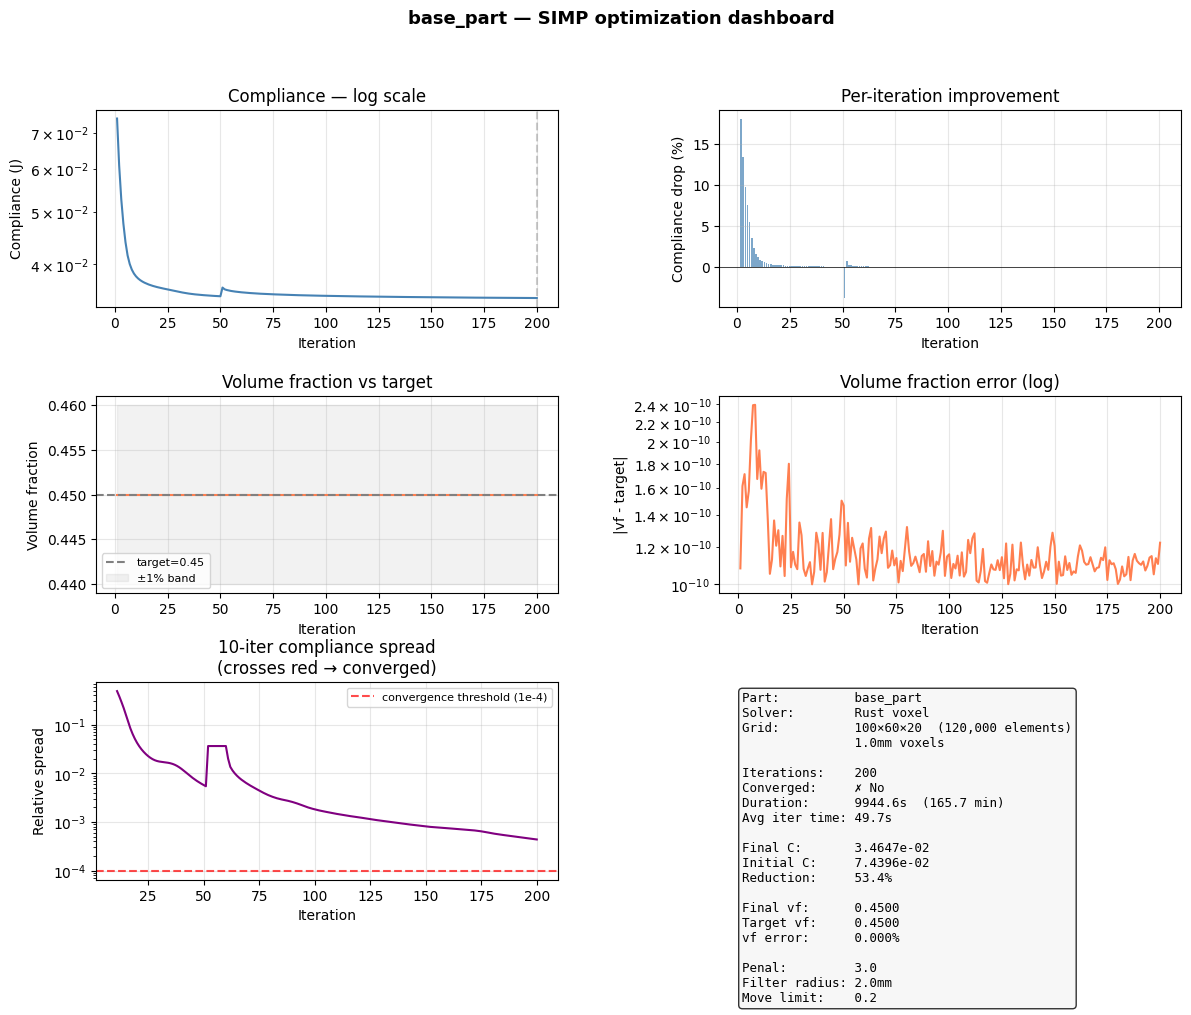

Dashboard saved: outputs/reports/base_part_convergence.png


In [6]:
# Cell 4 — SIMP convergence dashboard
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

compliance_history = result["compliance_history"]
volume_history     = result["volume_history"]
n_iterations       = result["n_iterations"]
converged          = result["converged"]
duration_s         = result["duration_s"]

vf_target = simp_config["volume_fraction"] if USE_RUST_SOLVER \
            else config_hard.volume_fraction

iters = np.arange(1, len(compliance_history) + 1)
compliance = np.array(compliance_history)
volume     = np.array(volume_history)

# ── Derived metrics ───────────────────────────────────────────────────────────
# Compliance improvement per iteration (relative drop)
c_drop = np.zeros_like(compliance)
c_drop[1:] = (compliance[:-1] - compliance[1:]) / (compliance[:-1] + 1e-30)

# Relative compliance spread over rolling 10-iteration window
c_spread = np.zeros_like(compliance)
for i in range(10, len(compliance)):
    window = compliance[i-10:i]
    c_spread[i] = (window.max() - window.min()) / (window.max() + 1e-30)

# Volume fraction error from target
vf_error = np.abs(volume - vf_target)

# Iteration wall time (estimated from duration_s / n_iterations)
avg_iter_s = duration_s / max(n_iterations, 1)

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax_c    = fig.add_subplot(gs[0, 0])   # compliance (log)
ax_cdp  = fig.add_subplot(gs[0, 1])   # compliance drop rate
ax_vf   = fig.add_subplot(gs[1, 0])   # volume fraction
ax_vfe  = fig.add_subplot(gs[1, 1])   # volume fraction error
ax_sp   = fig.add_subplot(gs[2, 0])   # compliance spread (convergence signal)
ax_info = fig.add_subplot(gs[2, 1])   # run summary text

# ── Compliance (log scale) ────────────────────────────────────────────────────
ax_c.semilogy(iters, compliance, color="steelblue", linewidth=1.5)
ax_c.axvline(n_iterations, color="gray", linestyle="--", alpha=0.4)
ax_c.set_ylabel("Compliance (J)")
ax_c.set_title("Compliance — log scale")
ax_c.grid(True, alpha=0.3)
ax_c.set_xlabel("Iteration")

# ── Per-iteration compliance improvement ──────────────────────────────────────
ax_cdp.bar(iters[1:], c_drop[1:] * 100, color="steelblue", alpha=0.7, width=0.8)
ax_cdp.axhline(0, color="black", linewidth=0.5)
ax_cdp.set_ylabel("Compliance drop (%)")
ax_cdp.set_title("Per-iteration improvement")
ax_cdp.grid(True, alpha=0.3)
ax_cdp.set_xlabel("Iteration")

# ── Volume fraction ───────────────────────────────────────────────────────────
ax_vf.plot(iters, volume, color="coral", linewidth=1.5)
ax_vf.axhline(vf_target, color="gray", linestyle="--",
              label=f"target={vf_target}")
ax_vf.fill_between(iters, vf_target - 0.01, vf_target + 0.01,
                   color="gray", alpha=0.1, label="±1% band")
ax_vf.set_ylabel("Volume fraction")
ax_vf.set_title("Volume fraction vs target")
ax_vf.legend(fontsize=8)
ax_vf.grid(True, alpha=0.3)
ax_vf.set_xlabel("Iteration")

# ── Volume fraction error ─────────────────────────────────────────────────────
ax_vfe.semilogy(iters, vf_error + 1e-10, color="coral", linewidth=1.5)
ax_vfe.set_ylabel("|vf - target|")
ax_vfe.set_title("Volume fraction error (log)")
ax_vfe.grid(True, alpha=0.3)
ax_vfe.set_xlabel("Iteration")

# ── Compliance spread (convergence signal) ────────────────────────────────────
ax_sp.semilogy(iters[10:], c_spread[10:] + 1e-10,
               color="purple", linewidth=1.5)
ax_sp.axhline(1e-4, color="red", linestyle="--", alpha=0.7,
              label="convergence threshold (1e-4)")
ax_sp.set_ylabel("Relative spread")
ax_sp.set_title("10-iter compliance spread\n(crosses red → converged)")
ax_sp.legend(fontsize=8)
ax_sp.grid(True, alpha=0.3)
ax_sp.set_xlabel("Iteration")

# ── Run summary ───────────────────────────────────────────────────────────────
ax_info.axis("off")
if USE_RUST_SOLVER:
    nx, ny, nz = grid_config["nx"], grid_config["ny"], grid_config["nz"]
    grid_str = f"{nx}×{ny}×{nz}  ({nx*ny*nz:,} elements)"
    voxel_str = f"{VOXEL_SIZE_MM}mm voxels"
else:
    grid_str = "FEniCSx tet mesh"
    voxel_str = f"~{FILTER_RADIUS}mm filter"

summary_lines = [
    f"Part:          {part_name}",
    f"Solver:        {'Rust voxel' if USE_RUST_SOLVER else 'FEniCSx'}",
    f"Grid:          {grid_str}",
    f"               {voxel_str}",
    f"",
    f"Iterations:    {n_iterations}",
    f"Converged:     {'✓ Yes' if converged else '✗ No'}",
    f"Duration:      {duration_s:.1f}s  ({duration_s/60:.1f} min)",
    f"Avg iter time: {avg_iter_s:.1f}s",
    f"",
    f"Final C:       {compliance[-1]:.4e}",
    f"Initial C:     {compliance[0]:.4e}",
    f"Reduction:     {(1 - compliance[-1]/compliance[0])*100:.1f}%",
    f"",
    f"Final vf:      {volume[-1]:.4f}",
    f"Target vf:     {vf_target:.4f}",
    f"vf error:      {abs(volume[-1]-vf_target)*100:.3f}%",
    f"",
    f"Penal:         {simp_config['penal'] if USE_RUST_SOLVER else PENAL}",
    f"Filter radius: {FILTER_RADIUS}mm",
    f"Move limit:    {MOVE_LIMIT}",
]

ax_info.text(0.05, 0.95, "\n".join(summary_lines),
             transform=ax_info.transAxes,
             fontsize=9, verticalalignment="top",
             fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="whitesmoke", alpha=0.8))

fig.suptitle(f"{part_name} — SIMP optimization dashboard",
             fontsize=13, fontweight="bold")

conv_path = report_dir / f"{part_name}_convergence.png"
plt.savefig(conv_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Dashboard saved: {conv_path}")

Cell 5 — Final density render

In [7]:
# Cell 5 — Render final density field
import numpy as np

if USE_RUST_SOLVER:
    density = result["density"]   # shape (nz, ny, nx), float32
    solid_count = int((density > 0.5).sum())
    total_count = density.size
    print(f"Density array: shape={density.shape}  "
          f"min={density.min():.3f}  max={density.max():.3f}")
    print(f"Solid elements (ρ>0.5): {solid_count:,} / {total_count:,} "
          f"({100*solid_count/total_count:.1f}%)")
    print(f"Density saved: outputs/meshes/{part_name}_density.npy")

    if RENDER_PLOTS:
        import matplotlib.pyplot as plt
        # Mid-slice through z for a quick 2D view
        z_mid = density.shape[0] // 2
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for ax, iz, label in zip(axes,
                                  [0, z_mid, density.shape[0]-1],
                                  ["Bottom (iz=0)", f"Mid (iz={z_mid})", "Top"]):
            ax.imshow(density[iz], vmin=0, vmax=1, cmap="bone", origin="lower")
            ax.set_title(label)
            ax.axis("off")
        plt.suptitle(f"{part_name} — density field slices")
        plt.tight_layout()
        slice_png = report_dir / f"{part_name}_density_slices.png"
        plt.savefig(slice_png, dpi=120, bbox_inches="tight")
        plt.show()
        print(f"Slice render: {slice_png}")
else:
    # FEniCSx path — original render logic
    if not RENDER_PLOTS:
        print("Skipping render — set RENDER_PLOTS=True after fixing display")
        print(f"Density field written to: {result['density_path']}")
    else:
        import pyvista as pv
        pv.OFF_SCREEN = True
        density_mesh = pv.read(str(result["density_path"]))
        solid = density_mesh.threshold(0.5, scalars="density")
        solid_fraction = solid.n_cells / density_mesh.n_cells
        print(f"Solid elements (ρ>0.5): {solid.n_cells:,} / "
              f"{density_mesh.n_cells:,} ({solid_fraction*100:.1f}%)")

Density array: shape=(20, 60, 100)  min=0.000  max=1.000
Solid elements (ρ>0.5): 57,822 / 120,000 (48.2%)
Density saved: outputs/meshes/base_part_density.npy


Cell 6 — Write Stage 4 handoff

In [8]:
# Cell 6 — Handoff for 05_stl_export.ipynb
import json
import dataclasses
from pathlib import Path

if USE_RUST_SOLVER:
    density_path_out = str(Path("outputs/meshes") / f"{part_name}_density.npy")
    solver_type = "rust_voxel"
    config_out = simp_config.copy()
    config_out["filter_radius_mm"] = FILTER_RADIUS
else:
    density_path_out = str(result.get("density_path", ""))
    solver_type = "fenicsx_tet"
    config_out = {
        "volume_fraction": config_hard.volume_fraction,
        "penal":           config_hard.penal,
        "filter_radius":   config_hard.filter_radius,
        "convergence_tol": config_hard.convergence_tol,
    }

handoff_out = {
    "stage":             "04_simp",
    "solver":            solver_type,
    "part_name":         part_name,
    "density_path":      density_path_out,
    "xdmf_path":         str(xdmf_path),
    "n_iterations":      result["n_iterations"],
    "converged":         result["converged"],
    "final_compliance":  result["final_compliance"],
    "final_volume_frac": result["final_volume_frac"],
    "duration_s":        result["duration_s"],
    "config":            config_out,
    "material":          material,
    "load_hints":        load_hints,
}
if USE_RUST_SOLVER:
    handoff_out["grid"] = result["grid"]

handoff_path_out = Path("outputs/meshes") / f"{part_name}_stage04.json"
handoff_path_out.write_text(json.dumps(handoff_out, indent=2))
print(f"Handoff written: {handoff_path_out}")
print(json.dumps(handoff_out, indent=2))

Handoff written: outputs/meshes/tripod_mount_base_stage04.json
{
  "stage": "04_simp",
  "solver": "rust_voxel",
  "part_name": "base_part",
  "density_path": "outputs/meshes/base_part_density.npy",
  "xdmf_path": "outputs/meshes/opt_domain.xdmf",
  "n_iterations": 150,
  "converged": false,
  "final_compliance": 0.03623557702936943,
  "final_volume_frac": 0.4500000000124899,
  "duration_s": 5378.949248488,
  "config": {
    "volume_fraction": 0.45,
    "penal": 3.0,
    "filter_radius": 0.003,
    "max_iterations": 150,
    "convergence_tol": 0.01,
    "move_limit": 0.2,
    "damping": 0.5,
    "checkpoint_every": 10,
    "filter_radius_mm": 3.0
  },
  "material": {
    "youngs_modulus_pa": 210000000000.0,
    "poissons_ratio": 0.3,
    "name": "steel"
  },
  "load_hints": {
    "primary_face": "top",
    "load_magnitude_n": 10000.0
  },
  "grid": {
    "nx": 100,
    "ny": 60,
    "nz": 20,
    "voxel_size": 0.001
  }
}


How Stage 4 connects to Stage 5
Two things travel forward:
density_path — the XDMF file containing the final rho field on the DG0 mesh. Stage 5 reads this, applies a threshold (default 0.5), and runs marching cubes via scikit-image to extract the isosurface as a triangle mesh. The threshold is configurable in Stage 5 — raising it (e.g. 0.6) gives a more conservative, heavier result; lowering it (e.g. 0.4) gives a lighter but more fragile one.
xdmf_path — the original mesh. Stage 5 needs the node coordinates to map the DG0 density field onto a regular voxel grid before marching cubes can run, since marching cubes expects a structured grid rather than an unstructured tet mesh.
The most important parameter connecting Stage 4 to Stage 5 is filter_radius. If it's too small relative to target_element_size, the density field will contain checkerboard noise that marching cubes turns into physically unmakeable thin spikes and disconnected islands in the STL. If your Stage 5 STL looks spiky or has disconnected components, come back here and increase FILTER_RADIUS by 50% and re-run from Cell 3.

In [9]:
import subprocess, json
from pathlib import Path

proc = subprocess.run(
    ["bin/simp_solver", "outputs/problem/problem.json"],
    capture_output=True, text=True
)
print(proc.stdout[:3000])   # first 3000 chars — first ~15 iterations

Grid: 100×60×20  (120000 elements, 388143 DOFs)
Material: E=2.100e11 Pa, ν=0.3
Config: vf=0.45, penal=3, r_filter=0.0030m, max_iter=150
Iter    1 | C=1.3700e-1 | Vol=0.450 | Δρ=5.5000e-1 | CG=929iters | 54.4s
Iter    2 | C=9.9893e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=892iters | 105.8s
Iter    3 | C=7.9267e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=852iters | 153.7s
Iter    4 | C=6.6016e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=903iters | 205.1s
Iter    5 | C=5.6289e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=982iters | 259.9s
Iter    6 | C=4.9383e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=990iters | 314.9s
Iter    7 | C=4.5038e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=915iters | 369.1s
Iter    8 | C=4.2263e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=880iters | 418.5s
Iter    9 | C=4.0465e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=882iters | 467.6s
Iter   10 | C=3.9303e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=856iters | 515.4s
Iter   11 | C=3.8558e-2 | Vol=0.450 | Δρ=1.0000e-1 | CG=856iters | 563.2s
Iter   12 | C=3.8087e-2 | Vol=0.450 | Δρ=1.0000e-1 